# Bitcoin Fraud Detection — GNN + Hybrid Models (Elliptic Dataset)

In [1]:
!pip install pyspark torch-geometric catboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.6 MB/s eta 0:00:0000:01


In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, classification_report

from catboost import CatBoostClassifier

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig
import matplotlib.patches as mpatches
import networkx as nx
from torch_geometric.utils import to_networkx

## Load & Preprocess

In [3]:
spark = SparkSession.builder.appName("EllipticFraud").getOrCreate()

features_path = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv"
classes_path  = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv"
edges_path    = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv"

features_sdf = spark.read.csv(features_path, inferSchema=True, header=False)
classes_sdf  = spark.read.csv(classes_path,  inferSchema=True, header=True)
edges_sdf    = spark.read.csv(edges_path,    inferSchema=True, header=True)

feature_columns = ["txId", "time_step"] + [f"f_{i}" for i in range(features_sdf.count() - 2)]
feature_columns = ["txId", "time_step"] + [f"f_{i}" for i in range(len(features_sdf.columns) - 2)]
features_sdf = features_sdf.toDF(*feature_columns)

merged_sdf = features_sdf.join(classes_sdf, on="txId", how="inner")
merged_sdf = merged_sdf.filter(col("class") != "unknown")
merged_sdf = merged_sdf.withColumn("class", when(col("class") == "1", 1).otherwise(0))

df = merged_sdf.toPandas()
print(f"Labelled transactions: {len(df)} | Illicit: {df['class'].sum()} | Licit: {(df['class']==0).sum()}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/20 10:27:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/20 10:27:46 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Labelled transactions: 46564 | Illicit: 4545 | Licit: 42019


## Temporal Train/Test Split (first 34 timesteps train, last 15 test)

In [4]:
node_ids = df["txId"].unique()
id_map   = {nid: idx for idx, nid in enumerate(node_ids)}
df["node_idx"] = df["txId"].map(id_map)

all_feature_cols   = [c for c in df.columns if c.startswith("f_")]   # 165 features
local_feature_cols = all_feature_cols[:93]                            # first 94 (index 0 = time_step)

X_af = df[all_feature_cols].values.astype(np.float32)
X_lf = df[local_feature_cols].values.astype(np.float32)
y_np = df["class"].astype(int).values
ts   = df["time_step"].values

train_idx = np.where(ts <= 34)[0]
test_idx  = np.where(ts  > 34)[0]

print(f"Train size: {len(train_idx)} | Test size: {len(test_idx)}")
print(f"Train illicit: {y_np[train_idx].sum()} | Test illicit: {y_np[test_idx].sum()}")

Train size: 29894 | Test size: 16670
Train illicit: 3462 | Test illicit: 1083


## Build Graph

In [5]:
edges_pd = edges_sdf.toPandas()
edges_pd = edges_pd[edges_pd["txId1"].isin(id_map) & edges_pd["txId2"].isin(id_map)]

source = edges_pd["txId1"].map(id_map).values
target = edges_pd["txId2"].map(id_map).values
edge_index = torch.tensor([source, target], dtype=torch.long)

X_af_t = torch.tensor(X_af, dtype=torch.float)
y_t    = torch.tensor(y_np, dtype=torch.long)

data = Data(x=X_af_t, edge_index=edge_index, y=y_t)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx]   = True
data.train_mask = train_mask
data.test_mask  = test_mask

print(data)

Data(x=[46564, 165], edge_index=[2, 36624], y=[46564], train_mask=[46564], test_mask=[46564])


/tmp/ipykernel_57/1265571566.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor([source, target], dtype=torch.long)


## Helper: Evaluate & Report

In [6]:
def report(name, y_true, y_pred):
    print(f"\n{'='*50}")
    print(f"{name}")
    print(classification_report(y_true, y_pred, target_names=["licit", "illicit"], digits=3))
    return f1_score(y_true, y_pred, pos_label=1)

## Baseline: Logistic Regression (LF and AF)

In [7]:
lr_lf = LogisticRegression(max_iter=1000, random_state=42)
lr_lf.fit(X_lf[train_idx], y_np[train_idx])
report("Logistic Regression — LF", y_np[test_idx], lr_lf.predict(X_lf[test_idx]))

lr_af = LogisticRegression(max_iter=1000, random_state=42)
lr_af.fit(X_af[train_idx], y_np[train_idx])
report("Logistic Regression — AF", y_np[test_idx], lr_af.predict(X_af[test_idx]))


Logistic Regression — LF
              precision    recall  f1-score   support

       licit      0.979     0.926     0.952     15587
     illicit      0.403     0.713     0.514      1083

    accuracy                          0.913     16670
   macro avg      0.691     0.820     0.733     16670
weighted avg      0.941     0.913     0.924     16670


Logistic Regression — AF
              precision    recall  f1-score   support

       licit      0.978     0.898     0.936     15587
     illicit      0.323     0.704     0.443      1083

    accuracy                          0.885     16670
   macro avg      0.650     0.801     0.689     16670
weighted avg      0.935     0.885     0.904     16670



0.4427658338175479

## Baseline: Random Forest (LF and AF)

In [8]:
rf_lf = RandomForestClassifier(n_estimators=100, max_features=50, random_state=42, n_jobs=-1)
rf_lf.fit(X_lf[train_idx], y_np[train_idx])
report("Random Forest — LF", y_np[test_idx], rf_lf.predict(X_lf[test_idx]))

rf_af = RandomForestClassifier(n_estimators=100, max_features=50, random_state=42, n_jobs=-1)
rf_af.fit(X_af[train_idx], y_np[train_idx])
report("Random Forest — AF", y_np[test_idx], rf_af.predict(X_af[test_idx]))


Random Forest — LF
              precision    recall  f1-score   support

       licit      0.979     0.992     0.985     15587
     illicit      0.853     0.697     0.767      1083

    accuracy                          0.973     16670
   macro avg      0.916     0.844     0.876     16670
weighted avg      0.971     0.973     0.971     16670


Random Forest — AF
              precision    recall  f1-score   support

       licit      0.981     0.996     0.989     15587
     illicit      0.928     0.723     0.813      1083

    accuracy                          0.978     16670
   macro avg      0.954     0.860     0.901     16670
weighted avg      0.978     0.978     0.977     16670



0.8126621691748832

## Feature Importance — Random Forest (AF)

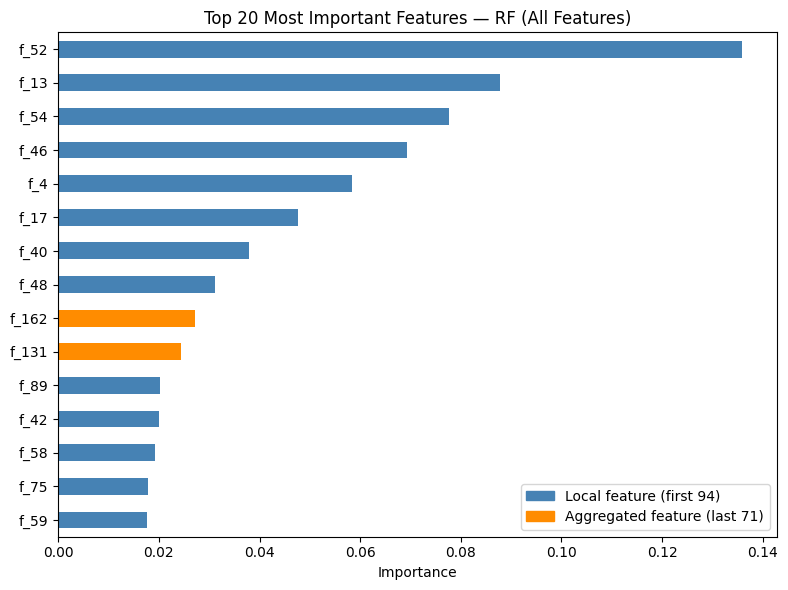

Top 20 breakdown — Local: 13 | Aggregated: 2


In [9]:
importances = pd.Series(rf_af.feature_importances_, index=all_feature_cols)
top20 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue" if c in local_feature_cols else "darkorange" for c in top20.index]
top20.sort_values().plot(kind="barh", ax=ax, color=list(reversed(colors)))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue",  label="Local feature (first 94)"),
    Patch(color="darkorange", label="Aggregated feature (last 71)")
], loc="lower right")

ax.set_title("Top 20 Most Important Features — RF (All Features)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

local_in_top20 = sum(c in local_feature_cols for c in top20.index)
agg_in_top20   = sum(c not in local_feature_cols for c in top20.index)
print(f"Top 20 breakdown — Local: {local_in_top20} | Aggregated: {agg_in_top20}")


## Baseline: MLP (LF and AF)

In [10]:
mlp_lf = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp_lf.fit(X_lf[train_idx], y_np[train_idx])
report("MLP — LF", y_np[test_idx], mlp_lf.predict(X_lf[test_idx]))

mlp_af = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp_af.fit(X_af[train_idx], y_np[train_idx])
report("MLP — AF", y_np[test_idx], mlp_af.predict(X_af[test_idx]))


MLP — LF
              precision    recall  f1-score   support

       licit      0.980     0.966     0.973     15587
     illicit      0.592     0.717     0.649      1083

    accuracy                          0.950     16670
   macro avg      0.786     0.842     0.811     16670
weighted avg      0.955     0.950     0.952     16670


MLP — AF
              precision    recall  f1-score   support

       licit      0.976     0.967     0.972     15587
     illicit      0.582     0.664     0.620      1083

    accuracy                          0.947     16670
   macro avg      0.779     0.815     0.796     16670
weighted avg      0.951     0.947     0.949     16670



0.6200948684777922

## Baseline: CatBoost

In [11]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=[1, 5],
    verbose=50,
    random_seed=42
)
cat_model.fit(X_af[train_idx], y_np[train_idx])
report("CatBoost — AF", y_np[test_idx], cat_model.predict(X_af[test_idx]))

0:	learn: 0.9355194	total: 173ms	remaining: 51.6s
50:	learn: 0.9795823	total: 4.24s	remaining: 20.7s
100:	learn: 0.9921920	total: 8.26s	remaining: 16.3s
150:	learn: 0.9976631	total: 12.2s	remaining: 12s
200:	learn: 0.9989609	total: 16.2s	remaining: 7.96s
250:	learn: 0.9993938	total: 20s	remaining: 3.91s
299:	learn: 0.9996535	total: 24s	remaining: 0us

CatBoost — AF
              precision    recall  f1-score   support

       licit      0.982     0.993     0.987     15587
     illicit      0.878     0.736     0.801      1083

    accuracy                          0.976     16670
   macro avg      0.930     0.864     0.894     16670
weighted avg      0.975     0.976     0.975     16670



0.8006027122049222

## Focal Loss

In [12]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()

## GAT Model

In [13]:
class GATModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4)
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels)
        self.lin   = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        embeddings = self.conv2(x, edge_index)
        out = self.lin(F.elu(embeddings))
        return out, embeddings

## Train GAT

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GATModel(
    in_channels=data.num_node_features,
    hidden_channels=128,
    out_channels=2
).to(device)

data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = FocalLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

def train_step():
    model.train()
    optimizer.zero_grad()
    out, _ = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(1, 401):
    loss = train_step()
    scheduler.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

Epoch 020 | Loss: 0.0340
Epoch 040 | Loss: 0.0278
Epoch 060 | Loss: 0.0247
Epoch 080 | Loss: 0.0223
Epoch 100 | Loss: 0.0208
Epoch 120 | Loss: 0.0205
Epoch 140 | Loss: 0.0197
Epoch 160 | Loss: 0.0193
Epoch 180 | Loss: 0.0185
Epoch 200 | Loss: 0.0179
Epoch 220 | Loss: 0.0180
Epoch 240 | Loss: 0.0175
Epoch 260 | Loss: 0.0173
Epoch 280 | Loss: 0.0171
Epoch 300 | Loss: 0.0167
Epoch 320 | Loss: 0.0167
Epoch 340 | Loss: 0.0167
Epoch 360 | Loss: 0.0165
Epoch 380 | Loss: 0.0166
Epoch 400 | Loss: 0.0163


## Focal Loss vs Weighted Cross-Entropy Comparison

Epoch 020 | Focal: 0.0379 | WCE: 0.2287
Epoch 040 | Focal: 0.0299 | WCE: 0.1691
Epoch 060 | Focal: 0.0265 | WCE: 0.1378
Epoch 080 | Focal: 0.0244 | WCE: 0.1185
Epoch 100 | Focal: 0.0227 | WCE: 0.1068
Epoch 120 | Focal: 0.0219 | WCE: 0.1032
Epoch 140 | Focal: 0.0215 | WCE: 0.0974
Epoch 160 | Focal: 0.0207 | WCE: 0.0951
Epoch 180 | Focal: 0.0200 | WCE: 0.0905
Epoch 200 | Focal: 0.0193 | WCE: 0.0868
Epoch 220 | Focal: 0.0194 | WCE: 0.0863
Epoch 240 | Focal: 0.0190 | WCE: 0.0831
Epoch 260 | Focal: 0.0192 | WCE: 0.0810
Epoch 280 | Focal: 0.0186 | WCE: 0.0790
Epoch 300 | Focal: 0.0185 | WCE: 0.0772
Epoch 320 | Focal: 0.0185 | WCE: 0.0768
Epoch 340 | Focal: 0.0184 | WCE: 0.0777
Epoch 360 | Focal: 0.0184 | WCE: 0.0777
Epoch 380 | Focal: 0.0181 | WCE: 0.0758
Epoch 400 | Focal: 0.0182 | WCE: 0.0739


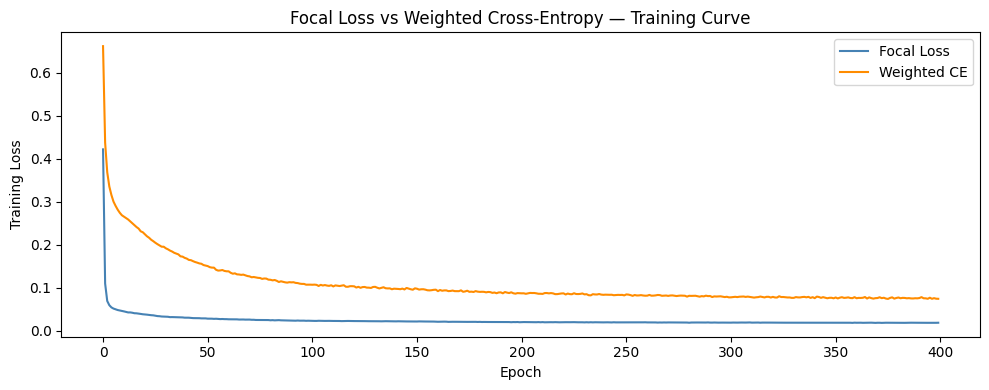


GAT — Weighted Cross-Entropy
              precision    recall  f1-score   support

       licit      0.976     0.948     0.962     15587
     illicit      0.471     0.671     0.554      1083

    accuracy                          0.930     16670
   macro avg      0.724     0.809     0.758     16670
weighted avg      0.944     0.930     0.935     16670


GAT — Focal Loss
              precision    recall  f1-score   support

       licit      0.974     0.952     0.963     15587
     illicit      0.480     0.639     0.548      1083

    accuracy                          0.932     16670
   macro avg      0.727     0.795     0.756     16670
weighted avg      0.942     0.932     0.936     16670



0.5481188118811882

In [15]:
model_wce = GATModel(
    in_channels=data.num_node_features,
    hidden_channels=128,
    out_channels=2
).to(device)

model_focal2 = GATModel(
    in_channels=data.num_node_features,
    hidden_channels=128,
    out_channels=2
).to(device)

optimizer_wce    = torch.optim.Adam(model_wce.parameters(),    lr=0.001, weight_decay=5e-4)
optimizer_focal2 = torch.optim.Adam(model_focal2.parameters(), lr=0.001, weight_decay=5e-4)
scheduler_wce    = torch.optim.lr_scheduler.StepLR(optimizer_wce,    step_size=100, gamma=0.5)
scheduler_focal2 = torch.optim.lr_scheduler.StepLR(optimizer_focal2, step_size=100, gamma=0.5)
criterion_wce    = nn.CrossEntropyLoss(weight=torch.tensor([0.3, 0.7]).to(device))
criterion_focal2 = FocalLoss()

wce_losses   = []
focal_losses = []

for epoch in range(1, 401):
    model_wce.train()
    optimizer_wce.zero_grad()
    out_wce, _ = model_wce(data.x, data.edge_index)
    loss_wce = criterion_wce(out_wce[data.train_mask], data.y[data.train_mask])
    loss_wce.backward()
    optimizer_wce.step()
    scheduler_wce.step()
    wce_losses.append(loss_wce.item())

    model_focal2.train()
    optimizer_focal2.zero_grad()
    out_f2, _ = model_focal2(data.x, data.edge_index)
    loss_f2 = criterion_focal2(out_f2[data.train_mask], data.y[data.train_mask])
    loss_f2.backward()
    optimizer_focal2.step()
    scheduler_focal2.step()
    focal_losses.append(loss_f2.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Focal: {focal_losses[-1]:.4f} | WCE: {wce_losses[-1]:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(focal_losses, label="Focal Loss",   color="steelblue")
plt.plot(wce_losses,   label="Weighted CE",  color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Focal Loss vs Weighted Cross-Entropy — Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

model_wce.eval()
model_focal2.eval()
with torch.no_grad():
    out_wce_test, _  = model_wce(data.x,    data.edge_index)
    out_f2_test,  _  = model_focal2(data.x, data.edge_index)

preds_wce    = out_wce_test.argmax(dim=1)[data.test_mask].cpu().numpy()
preds_focal2 = out_f2_test.argmax(dim=1)[data.test_mask].cpu().numpy()
true_labels  = data.y[data.test_mask].cpu().numpy()

report("GAT — Weighted Cross-Entropy", true_labels, preds_wce)
report("GAT — Focal Loss",             true_labels, preds_focal2)


## Evaluate GAT

In [16]:
model.eval()
with torch.no_grad():
    out, embeddings = model(data.x, data.edge_index)
    preds = out.argmax(dim=1)

test_preds  = preds[data.test_mask].cpu().numpy()
test_labels = data.y[data.test_mask].cpu().numpy()
embeddings_np = embeddings.cpu().numpy()

report("GAT", test_labels, test_preds)


GAT
              precision    recall  f1-score   support

       licit      0.974     0.954     0.964     15587
     illicit      0.492     0.640     0.556      1083

    accuracy                          0.934     16670
   macro avg      0.733     0.797     0.760     16670
weighted avg      0.943     0.934     0.938     16670



0.5564030509835407

## GNNExplainer — AML Typology Mapping

Generating explanations for illicit transactions...
  Node 29897 | True: Illicit | Pred: Illicit | Typology: Structuring
  Node 29898 | True: Illicit | Pred: Illicit | Typology: Structuring
  Node 29912 | True: Illicit | Pred: Illicit | Typology: Structuring
  Node 29930 | True: Illicit | Pred: Illicit | Typology: Structuring
  Node 29935 | True: Illicit | Pred: Illicit | Typology: Structuring

Generating explanations for licit transactions...
  Node 29894 | True: Licit | Pred: Licit | Typology: Structuring
  Node 29895 | True: Licit | Pred: Licit | Typology: Structuring
  Node 29896 | True: Licit | Pred: Licit | Typology: Structuring


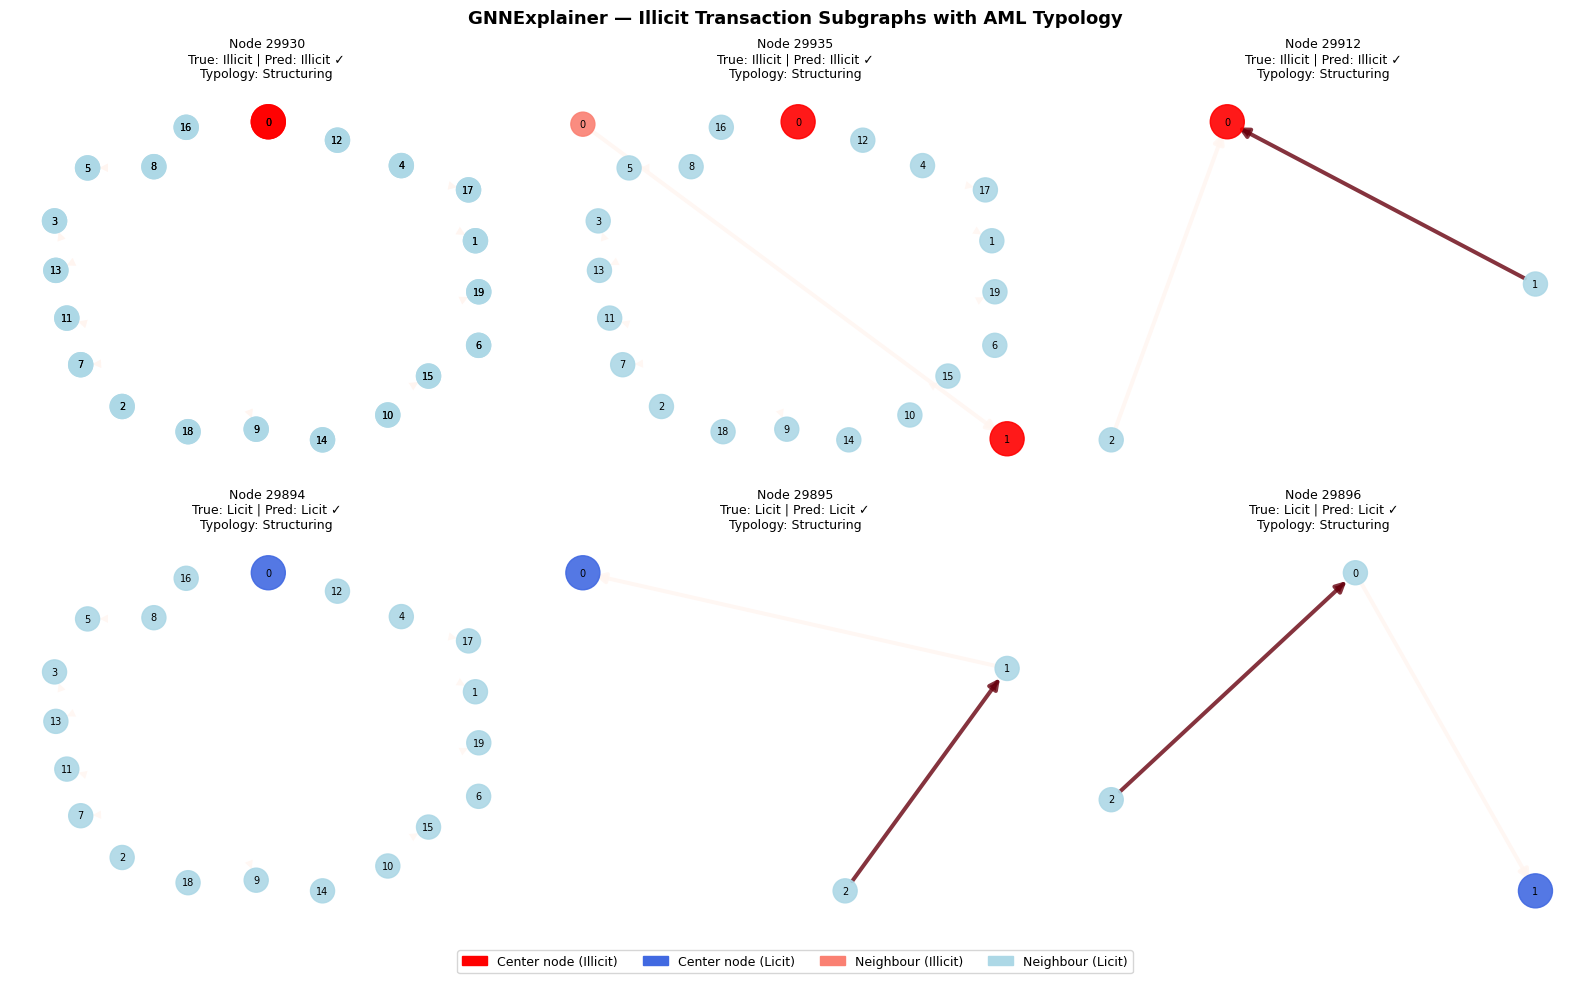


AML Typology Distribution (Illicit nodes):
  Structuring: 5 — Breaking large amounts into smaller transactions to avoid detection


In [17]:
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig
import matplotlib.patches as mpatches
import networkx as nx

class GATModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x, edge_index):
        out, _ = self.model(x, edge_index)
        return out

wrapped_model = GATModelWrapper(model).to(device)
wrapped_model.eval()

AML_TYPOLOGIES = {
    "Layering":    "Multiple hops moving funds through intermediaries to obscure origin",
    "Structuring": "Breaking large amounts into smaller transactions to avoid detection",
    "Fan-out":     "Single illicit source distributing to many outputs simultaneously",
    "Fan-in":      "Many inputs consolidating into a single illicit destination",
    "Pass-through":"Rapid movement with minimal holding — funds in and out quickly",
}

explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=300),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=ModelConfig(
        mode="multiclass_classification",
        task_level="node",
        return_type="raw",
    ),
)

test_node_indices  = data.test_mask.nonzero(as_tuple=True)[0]
illicit_test_nodes = test_node_indices[data.y[test_node_indices] == 1]
licit_test_nodes   = test_node_indices[data.y[test_node_indices] == 0]

illicit_samples = illicit_test_nodes[:5].tolist()
licit_samples   = licit_test_nodes[:3].tolist()

def classify_subgraph_typology(edge_index_sub, node_labels, center_idx):
    if edge_index_sub.shape[1] == 0:
        return "Insufficient edges"
    out_edges = (edge_index_sub[0] == center_idx).sum().item()
    in_edges  = (edge_index_sub[1] == center_idx).sum().item()
    n_nodes   = node_labels.shape[0]
    if out_edges >= 3 and in_edges <= 1:
        return "Fan-out"
    elif in_edges >= 3 and out_edges <= 1:
        return "Fan-in"
    elif n_nodes >= 4 and out_edges >= 1 and in_edges >= 1:
        return "Layering"
    elif out_edges == 1 and in_edges == 1:
        return "Pass-through"
    else:
        return "Structuring"

def plot_explanation_subgraph(explanation, node_idx, true_label, pred_label, ax):
    edge_mask      = explanation.edge_mask
    node_feat_mask = explanation.node_mask
    sig_edges = (edge_mask > 0.3).nonzero(as_tuple=True)[0]
    if sig_edges.shape[0] == 0:
        sig_edges = edge_mask.topk(min(10, edge_mask.shape[0])).indices
    sub_edge_index = explanation.edge_index[:, sig_edges]
    involved_nodes = sub_edge_index.unique()
    node_map       = {n.item(): i for i, n in enumerate(involved_nodes)}
    center_local   = node_map.get(node_idx, 0)
    G = nx.DiGraph()
    for n in involved_nodes.tolist():
        G.add_node(node_map[n])
    for e in range(sub_edge_index.shape[1]):
        src = node_map.get(sub_edge_index[0, e].item())
        dst = node_map.get(sub_edge_index[1, e].item())
        if src is not None and dst is not None:
            G.add_edge(src, dst, weight=edge_mask[sig_edges[e]].item())
    typology = classify_subgraph_typology(
        sub_edge_index - sub_edge_index.min(),
        node_feat_mask,
        center_local
    )
    pos         = nx.spring_layout(G, seed=42, k=2)
    node_colors = []
    node_sizes  = []
    for n in G.nodes():
        if n == center_local:
            node_colors.append("red" if true_label == 1 else "royalblue")
            node_sizes.append(600)
        else:
            orig_idx = involved_nodes[n].item() if n < len(involved_nodes) else -1
            label    = data.y[orig_idx].item() if 0 <= orig_idx < data.y.shape[0] else 0
            node_colors.append("salmon" if label == 1 else "lightblue")
            node_sizes.append(300)
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=[w * 3 for w in edge_weights],
                           edge_color=edge_weights, edge_cmap=plt.cm.Reds,
                           ax=ax, arrows=True, arrowsize=15, alpha=0.8)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    pred_str = "Illicit" if pred_label == 1 else "Licit"
    true_str = "Illicit" if true_label == 1 else "Licit"
    correct  = "✓" if pred_label == true_label else "✗"
    ax.set_title(
        f"Node {node_idx}\nTrue: {true_str} | Pred: {pred_str} {correct}\nTypology: {typology}",
        fontsize=9, pad=8
    )
    ax.axis("off")
    return typology

with torch.no_grad():
    out_all, _ = model(data.x, data.edge_index)
all_preds = out_all.argmax(dim=1)

print("Generating explanations for illicit transactions...")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("GNNExplainer — Illicit Transaction Subgraphs with AML Typology", fontsize=13, fontweight="bold")

typology_counts = {}

for i, node_idx in enumerate(illicit_samples):
    explanation = explainer(data.x, data.edge_index, index=node_idx)
    true_label  = data.y[node_idx].item()
    pred_label  = all_preds[node_idx].item()
    typology    = plot_explanation_subgraph(explanation, node_idx, true_label, pred_label, axes[0, i % 3])
    typology_counts[typology] = typology_counts.get(typology, 0) + 1
    print(f"  Node {node_idx} | True: {'Illicit' if true_label==1 else 'Licit'} | Pred: {'Illicit' if pred_label==1 else 'Licit'} | Typology: {typology}")

print("\nGenerating explanations for licit transactions...")
for i, node_idx in enumerate(licit_samples):
    explanation = explainer(data.x, data.edge_index, index=node_idx)
    true_label  = data.y[node_idx].item()
    pred_label  = all_preds[node_idx].item()
    typology    = plot_explanation_subgraph(explanation, node_idx, true_label, pred_label, axes[1, i % 3])
    print(f"  Node {node_idx} | True: {'Illicit' if true_label==1 else 'Licit'} | Pred: {'Illicit' if pred_label==1 else 'Licit'} | Typology: {typology}")

legend_elements = [
    mpatches.Patch(color="red",       label="Center node (Illicit)"),
    mpatches.Patch(color="royalblue", label="Center node (Licit)"),
    mpatches.Patch(color="salmon",    label="Neighbour (Illicit)"),
    mpatches.Patch(color="lightblue", label="Neighbour (Licit)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print("\nAML Typology Distribution (Illicit nodes):")
for t, count in typology_counts.items():
    print(f"  {t}: {count} — {AML_TYPOLOGIES[t]}")


## GNNExplainer — Feature Importance (Graph-Aware)

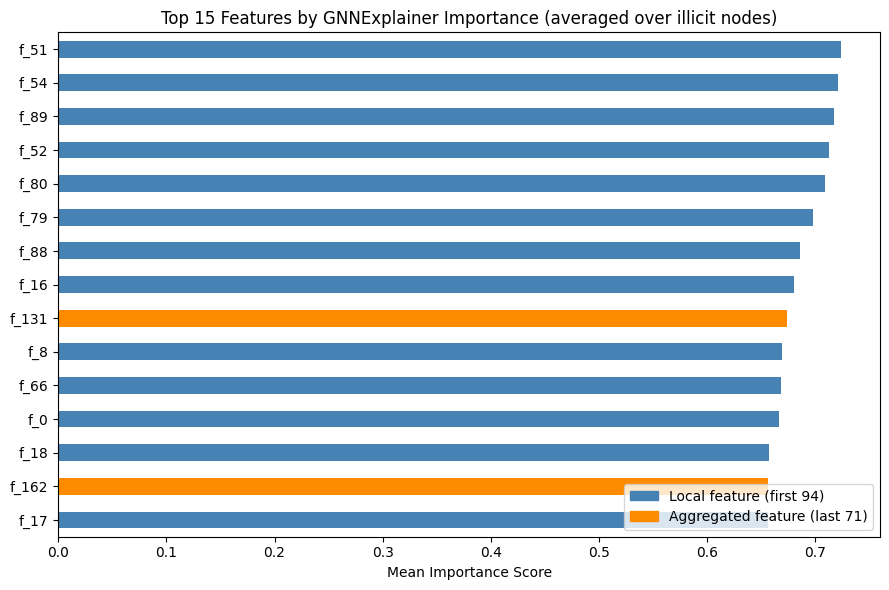

Top 15 GNNExplainer breakdown — Local: 13 | Aggregated: 2
Compare with RF importance   — Local: 18 | Aggregated: 2


In [18]:
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig

class GATModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x, edge_index):
        out, _ = self.model(x, edge_index)
        return out

wrapped_model_feat = GATModelWrapper(model).to(device)
wrapped_model_feat.eval()

feat_explainer = Explainer(
    model=wrapped_model_feat,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=ModelConfig(
        mode="multiclass_classification",
        task_level="node",
        return_type="raw",
    ),
)

test_node_indices  = data.test_mask.nonzero(as_tuple=True)[0]
illicit_test_nodes = test_node_indices[data.y[test_node_indices] == 1]
sample_nodes       = illicit_test_nodes[:30].tolist()

all_node_masks = []
for node_idx in sample_nodes:
    try:
        exp = feat_explainer(data.x, data.edge_index, index=node_idx)
        all_node_masks.append(exp.node_mask[node_idx].cpu().numpy())
    except Exception as e:
        print(f"Skipped node {node_idx}: {e}")

mean_importance = np.array(all_node_masks).mean(axis=0)
feat_imp_series = pd.Series(mean_importance, index=all_feature_cols)
top15 = feat_imp_series.nlargest(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["steelblue" if c in local_feature_cols else "darkorange" for c in top15.index]
top15.sort_values().plot(kind="barh", ax=ax, color=list(reversed(colors)))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue",   label="Local feature (first 94)"),
    Patch(color="darkorange",  label="Aggregated feature (last 71)")
], loc="lower right")

ax.set_title("Top 15 Features by GNNExplainer Importance (averaged over illicit nodes)")
ax.set_xlabel("Mean Importance Score")
plt.tight_layout()
plt.show()

local_count = sum(c in local_feature_cols for c in top15.index)
agg_count   = sum(c not in local_feature_cols for c in top15.index)
print(f"Top 15 GNNExplainer breakdown — Local: {local_count} | Aggregated: {agg_count}")
print(f"Compare with RF importance   — Local: 18 | Aggregated: 2")


## Hybrid: GAT Embeddings + Original Features → CatBoost (AF+NE)

In [19]:
X_train_hybrid = np.concatenate([X_af[train_idx], embeddings_np[train_idx]], axis=1)
X_test_hybrid  = np.concatenate([X_af[test_idx],  embeddings_np[test_idx]],  axis=1)

hybrid_cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=[1, 5],
    verbose=50,
    random_seed=42
)
hybrid_cat.fit(X_train_hybrid, y_np[train_idx])
report("Hybrid GAT+CatBoost — AF+NE", test_labels, hybrid_cat.predict(X_test_hybrid))

hybrid_rf = RandomForestClassifier(n_estimators=100, max_features=50, random_state=42, n_jobs=-1)
hybrid_rf.fit(X_train_hybrid, y_np[train_idx])
report("Hybrid GAT+RandomForest — AF+NE", test_labels, hybrid_rf.predict(X_test_hybrid))

0:	learn: 0.9324406	total: 204ms	remaining: 1m
50:	learn: 0.9842485	total: 7.45s	remaining: 36.4s
100:	learn: 0.9944289	total: 14.7s	remaining: 29s
150:	learn: 0.9980673	total: 21.9s	remaining: 21.6s
200:	learn: 0.9990765	total: 29s	remaining: 14.3s
250:	learn: 0.9995092	total: 36.1s	remaining: 7.04s
299:	learn: 0.9996824	total: 43s	remaining: 0us

Hybrid GAT+CatBoost — AF+NE
              precision    recall  f1-score   support

       licit      0.980     0.984     0.982     15587
     illicit      0.752     0.708     0.729      1083

    accuracy                          0.966     16670
   macro avg      0.866     0.846     0.856     16670
weighted avg      0.965     0.966     0.965     16670


Hybrid GAT+RandomForest — AF+NE
              precision    recall  f1-score   support

       licit      0.979     0.995     0.987     15587
     illicit      0.910     0.692     0.786      1083

    accuracy                          0.976     16670
   macro avg      0.945     0.843     0.886

0.7859391395592865

## Per-Timestep Illicit F1 (Figure 2 equivalent)

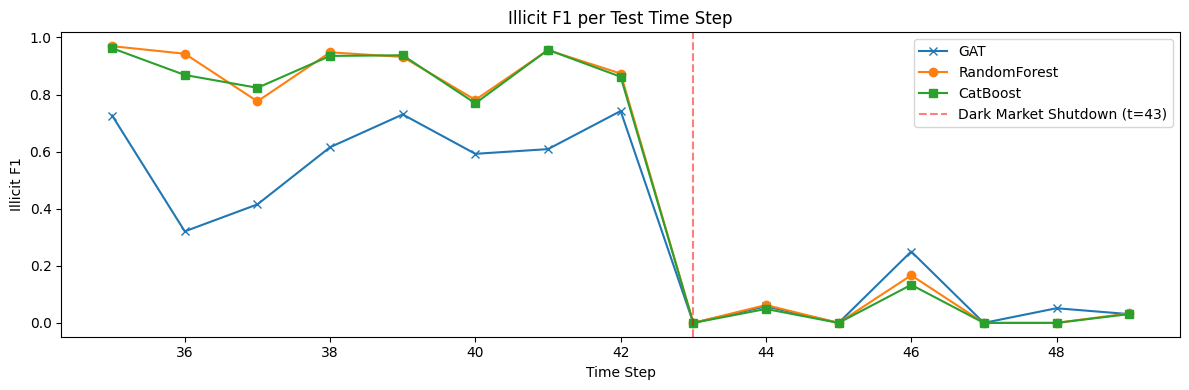

In [20]:
ts_test = ts[test_idx]

gat_f1_per_ts  = {}
rf_f1_per_ts   = {}
cat_f1_per_ts  = {}

for t in sorted(np.unique(ts_test)):
    mask = ts_test == t
    if mask.sum() == 0 or y_np[test_idx][mask].sum() == 0:
        continue
    true = y_np[test_idx][mask]
    gat_f1_per_ts[t]  = f1_score(true, test_preds[mask],                               pos_label=1, zero_division=0)
    rf_f1_per_ts[t]   = f1_score(true, rf_af.predict(X_af[test_idx][mask]),             pos_label=1, zero_division=0)
    cat_f1_per_ts[t]  = f1_score(true, cat_model.predict(X_af[test_idx][mask]),         pos_label=1, zero_division=0)

plt.figure(figsize=(12, 4))
plt.plot(list(gat_f1_per_ts.keys()),  list(gat_f1_per_ts.values()),  label="GAT",          marker="x")
plt.plot(list(rf_f1_per_ts.keys()),   list(rf_f1_per_ts.values()),   label="RandomForest", marker="o")
plt.plot(list(cat_f1_per_ts.keys()),  list(cat_f1_per_ts.values()),  label="CatBoost",     marker="s")
plt.axvline(x=43, color="red", linestyle="--", alpha=0.5, label="Dark Market Shutdown (t=43)")
plt.xlabel("Time Step")
plt.ylabel("Illicit F1")
plt.title("Illicit F1 per Test Time Step")
plt.legend()
plt.tight_layout()
plt.show()

## Summary Table

In [21]:
results = {
    "LR — LF":               f1_score(y_np[test_idx], lr_lf.predict(X_lf[test_idx]),   pos_label=1),
    "LR — AF":               f1_score(y_np[test_idx], lr_af.predict(X_af[test_idx]),   pos_label=1),
    "RF — LF":               f1_score(y_np[test_idx], rf_lf.predict(X_lf[test_idx]),   pos_label=1),
    "RF — AF":               f1_score(y_np[test_idx], rf_af.predict(X_af[test_idx]),   pos_label=1),
    "MLP — LF":              f1_score(y_np[test_idx], mlp_lf.predict(X_lf[test_idx]),  pos_label=1),
    "MLP — AF":              f1_score(y_np[test_idx], mlp_af.predict(X_af[test_idx]),  pos_label=1),
    "CatBoost — AF":         f1_score(y_np[test_idx], cat_model.predict(X_af[test_idx]), pos_label=1),
    "GAT":                   f1_score(test_labels, test_preds,                          pos_label=1),
    "GAT+CatBoost — AF+NE":  f1_score(test_labels, hybrid_cat.predict(X_test_hybrid),  pos_label=1),
    "GAT+RF — AF+NE":        f1_score(test_labels, hybrid_rf.predict(X_test_hybrid),   pos_label=1),
}

summary_df = pd.DataFrame.from_dict(results, orient="index", columns=["Illicit F1"])
summary_df = summary_df.sort_values("Illicit F1", ascending=False)
print(summary_df.to_string(float_format="{:.3f}".format))

                      Illicit F1
RF — AF                    0.813
CatBoost — AF              0.801
GAT+RF — AF+NE             0.786
RF — LF                    0.767
GAT+CatBoost — AF+NE       0.729
MLP — LF                   0.649
MLP — AF                   0.620
GAT                        0.556
LR — LF                    0.514
LR — AF                    0.443


## Save Models

In [22]:
os.makedirs("saved_models", exist_ok=True)

joblib.dump(rf_af,      "saved_models/random_forest_af.pkl")
joblib.dump(rf_lf,      "saved_models/random_forest_lf.pkl")
joblib.dump(hybrid_rf,  "saved_models/hybrid_rf_af_ne.pkl")
cat_model.save_model(   "saved_models/catboost_af.cbm")
hybrid_cat.save_model(  "saved_models/hybrid_catboost_af_ne.cbm")
torch.save(model.state_dict(), "saved_models/gat_model.pth")

zip_path = "elliptic_models.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for root, _, files in os.walk("saved_models"):
        for f in files:
            zf.write(os.path.join(root, f), arcname=f)

print("Saved:", zip_path)

Saved: elliptic_models.zip
